In [2]:
import pandas as pd

# 1. Читаем файл с учетом табуляции
df = pd.read_csv('data.csv', sep='\t')

# 2. Создаем целевую переменную (суммируем баллы по Макиавеллизму)
m_columns = [f'M{i}' for i in range(1, 10)]
df['target_mach'] = df[m_columns].sum(axis=1)

# 3. Подготовим данные: удалим текстовые колонки и саму цель из признаков
X = df.drop(['country', 'source', 'target_mach'], axis=1)
y = df['target_mach']

# Посмотрим, что получилось
print("Формат данных:", X.shape)
print("Пример целевой переменной:", y.head())
X.head()

Формат данных: (18192, 27)
Пример целевой переменной: 0    35
1    20
2    29
3    44
4    34
Name: target_mach, dtype: int64


,M1,M2,M3,M4,M5,M6,M7,M8,M9,N1,...,N9,P1,P2,P3,P4,P5,P6,P7,P8,P9
0,4,4,4,4,4,4,4,3,4,2,...,4,3,4,3,2,4,4,4,4,4
1,2,1,5,2,2,1,2,2,3,1,...,2,1,1,1,5,4,1,5,3,2
2,3,3,3,5,1,1,5,5,3,2,...,5,3,5,3,1,3,1,2,3,1
3,5,5,4,5,5,5,5,5,5,5,...,5,5,1,5,2,5,5,5,1,5
4,4,4,2,5,5,5,4,1,4,3,...,5,4,5,3,1,4,3,5,4,1


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Загрузка и создание целевой переменной для Макиавеллизма
df = pd.read_csv('data.csv', sep='\t')
m_columns = [f'M{i}' for i in range(1, 10)]
df['target_mach'] = df[m_columns].sum(axis=1)

# 2. Подготовка X и y
X = df.drop(['country', 'source', 'target_mach'], axis=1)
y = df['target_mach']

# 3. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Список моделей
models = [
    ("Linear Regression", LinearRegression()),
    ("Lasso", Lasso(alpha=0.1)),
    ("Random Forest", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
    ("LGBM", LGBMRegressor(random_state=42, verbose=-1)),
    ("KNN", KNeighborsRegressor(n_neighbors=5))
]

results_mach = []

# 5. Цикл обучения
for name, model in models:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results_mach.append({"Модель": name, "R2 (Макиавеллизм)": r2, "MAE": mae})

# Вывод
mach_df = pd.DataFrame(results_mach).sort_values(by="R2 (Макиавеллизм)", ascending=False)
print(mach_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


              Модель  R2 (Макиавеллизм)           MAE
0  Linear Regression           1.000000  4.164651e-14
1              Lasso           0.999556  1.207634e-01
3               LGBM           0.997019  2.728160e-01
2      Random Forest           0.982568  6.261940e-01
4                KNN           0.956912  1.156801e+00


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Загрузка (укажите ваш разделитель)
df = pd.read_csv('data.csv', sep='\t')

# 2. Обработка Психопатии (P1-P9)
p_cols = [f'P{i}' for i in range(1, 10)]
# Инвертируем P2 и P7 (шкала 1-5: 6 - x)
df['P2'] = 6 - df['P2']
df['P7'] = 6 - df['P7']
# Целевая переменная - сумма баллов психопатии
df['target_psych'] = df[p_cols].sum(axis=1)

# 3. Подготовка признаков (X) и цели (y)
# УДАЛЯЕМ p_cols из X, чтобы не было "подсказок" (утечки данных)
X = df.drop(['country', 'source', 'target_psych'] + p_cols, axis=1)
y = df['target_psych']

# 4. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Список 7 регрессоров
models_list = [
    ("Linear Regression", LinearRegression()),
    ("Lasso", Lasso(alpha=0.1)),
    ("Random Forest", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
    ("LGBM", LGBMRegressor(random_state=42, verbose=-1)),
    ("AdaBoost", AdaBoostRegressor(random_state=42)),
    ("Elastic Net", ElasticNet(alpha=0.1)),
    ("Dummy (Baseline)", DummyRegressor(strategy="mean"))
]

results = []

# 6. Обучение и оценка
for name, model in models_list:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results.append({
        "Модель": name,
        "R2 Score": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds)
    })

# Итоговая таблица
final_comparison = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(final_comparison)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


              Модель  R2 Score       MAE
3               LGBM  0.593940  3.639655
0  Linear Regression  0.585383  3.682254
5        Elastic Net  0.584050  3.688032
1              Lasso  0.583485  3.689863
2      Random Forest  0.566237  3.779370
4           AdaBoost  0.540468  3.929690
6   Dummy (Baseline) -0.000584  5.925808


/tmp/ipykernel_703/244182853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Важность', y='Признак', data=importance.head(10), palette='magma')


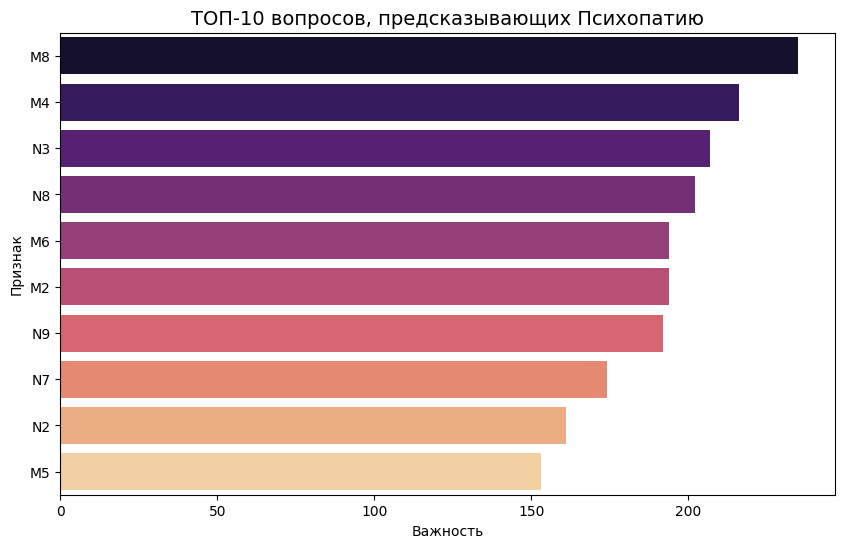

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берем обученную модель LGBM (она была под индексом 3 в списке или в переменной, если сохраняли)
# Для надежности переобучим лучшую модель отдельно:
best_model = LGBMRegressor(random_state=42, verbose=-1)
best_model.fit(X_train_scaled, y_train)

# Получаем важность признаков
importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': best_model.feature_importances_
}).sort_values(by='Важность', ascending=False)

# Визуализация ТОП-10
plt.figure(figsize=(10, 6))
sns.barplot(x='Важность', y='Признак', data=importance.head(10), palette='magma')
plt.title('ТОП-10 вопросов, предсказывающих Психопатию', fontsize=14)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


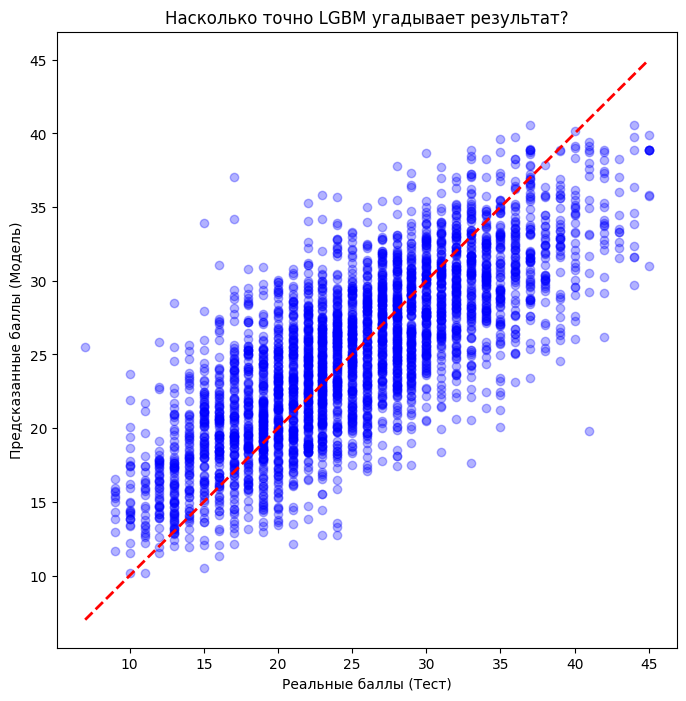

In [9]:
preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, preds, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные баллы (Тест)')
plt.ylabel('Предсказанные баллы (Модель)')
plt.title('Насколько точно LGBM угадывает результат?')
plt.show()

In [10]:
import numpy as np

# Введите свои ответы (1-5) вместо этих примеров:
# Вопросы M1-M9, затем N1-N9 (N2 мы инвертировали ранее, вводите как есть)
my_responses = [
    5, 1, 3, 3, 1, 1, 5, 3, 3, # Макиавеллизм (M1-M9)
    2, 2, 1, 1, 5, 1, 1, 5, 4  # Нарциссизм (N1-N9)
]

# Превращаем в формат, который понимает модель
my_data = np.array(my_responses).reshape(1, -1)

# ВАЖНО: Применяем инверсию к N2 (десятый элемент в списке, индекс 9)
# Мы делали это для обучения, значит должны сделать и для предсказания
my_data[0, 9] = 6 - my_data[0, 9]

# Масштабируем данные тем же скалером, что и при обучении
my_data_scaled = scaler.transform(my_data)

# Предсказываем балл лучшей моделью (LGBM)
my_prediction = best_model.predict(my_data_scaled)

print(f"Ваш предсказанный балл Психопатии: {my_prediction[0]:.2f}")
print("Для справки: минимальный балл 9, максимальный 45.")

Ваш предсказанный балл Психопатии: 15.24
Для справки: минимальный балл 9, максимальный 45.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/tmp/ipykernel_703/1823066546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Модель', data=final_comparison, palette='coolwarm')


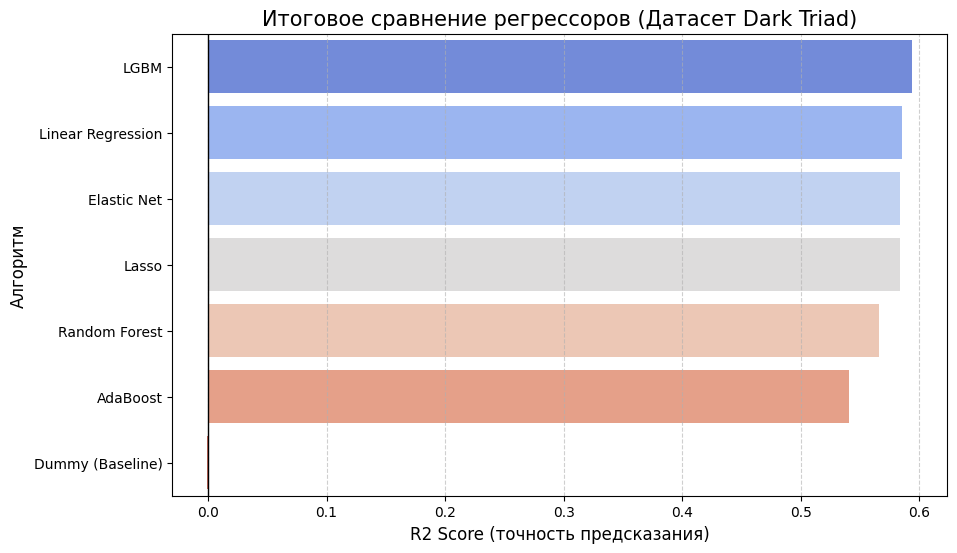

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль
plt.figure(figsize=(10, 6))
# final_comparison — это таблица, которую мы создали ранее
sns.barplot(x='R2 Score', y='Модель', data=final_comparison, palette='coolwarm')

# Добавляем детали
plt.axvline(0, color='black', lw=1) # Линия нуля для Dummy
plt.title('Итоговое сравнение регрессоров (Датасет Dark Triad)', fontsize=15)
plt.xlabel('R2 Score (точность предсказания)', fontsize=12)
plt.ylabel('Алгоритм', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()